# 🔥 Algerian Forest Fires Dataset

## 📌 Overview
The **Algerian Forest Fires Dataset** contains meteorological and fire occurrence data collected from two regions of Algeria:
- Bejaia (Northeast)
- Sidi Bel-Abbes (Northwest)

The dataset is widely used for **machine learning classification and regression tasks**, especially for predicting forest fire occurrences.

- 📅 Time Period: June 2012 – September 2012  
- 📊 Total Instances: 244  
- 🌍 Regions: 2 (122 records each)  
- 🎯 Target Variable: Fire / Not Fire  

According to the dataset description, it includes **11 input features and 1 output class**. :contentReference[oaicite:0]{index=0}  

---

## 🎯 Objective
The main goal is to:
- Predict whether a forest fire will occur
- Analyze environmental conditions affecting fires
- Build ML models for classification or regression

---

## 📂 Dataset Features

### 🧾 Date Information
- `Date` → Format: DD/MM/YYYY

### 🌦️ Weather Attributes
- `Temp` → Temperature (°C)
- `RH` → Relative Humidity (%)
- `Ws` → Wind Speed (km/h)
- `Rain` → Rainfall (mm)

### 🔥 Fire Weather Index (FWI) Components
- `FFMC` → Fine Fuel Moisture Code  
- `DMC` → Duff Moisture Code  
- `DC` → Drought Code  
- `ISI` → Initial Spread Index  
- `BUI` → Buildup Index  
- `FWI` → Fire Weather Index  

### 🎯 Target Variable
- `Classes` → 
  - `Fire`
  - `Not Fire`

---

## 📊 Key Insights
- Total Fire Cases: **138**
- Total Non-Fire Cases: **106**
- Dataset is slightly **imbalanced towards fire cases** :contentReference[oaicite:1]{index=1}  

---

## 🧠 Use Cases
This dataset can be used for:
- 🔹 Classification (Fire vs Not Fire)
- 🔹 Regression (Predicting FWI index)
- 🔹 Feature Engineering & EDA
- 🔹 Time-based analysis
- 🔹 Climate impact studies

---

## ⚙️ Machine Learning Applications
Common algorithms used:
- Logistic Regression
- Decision Trees
- Random Forest
- Gradient Boosting
- Support Vector Machines

---

## 📈 Example Problem Statements
- Predict if a fire will occur based on weather conditions
- Analyze which feature contributes most to fire occurrence
- Forecast fire intensity using FWI

---

## 🧹 Data Preprocessing Ideas
- Handle categorical encoding (`Classes`)
- Feature scaling (StandardScaler / MinMaxScaler)
- Remove correlated features (e.g., DC & BUI)
- Extract date features (month, day)

---

## 📎 Source
Kaggle Dataset:  
https://www.kaggle.com/datasets/nitinchoudhary012/algerian-forest-fires-dataset

---

## 🏷️ License
ODC Public Domain Dedication and Licence (PDDL)

---

## 🙌 Credits
Dataset provided for research and educational purposes on Kaggle.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
dataset = pd.read_csv('../../data/Algerian_forest_fires_dataset.csv')
print("Head\n",dataset.head())
print("Description\n",dataset.describe())
print("Info\n",dataset.info())
print("Null values\n",dataset.isnull().sum())

Head
   day month  year Temperature  RH  Ws Rain   FFMC  DMC    DC  ISI  BUI  FWI  \
0   1     6  2012          29  57  18     0  65.7  3.4   7.6  1.3  3.4  0.5   
1   2     6  2012          29  61  13   1.3  64.4  4.1   7.6    1  3.9  0.4   
2   3     6  2012          26  82  22  13.1  47.1  2.5   7.1  0.3  2.7  0.1   
3   4     6  2012          25  89  13   2.5  28.6  1.3   6.9    0  1.7    0   
4   5     6  2012          27  77  16     0  64.8    3  14.2  1.2  3.9  0.5   

     Classes    
0  not fire     
1  not fire     
2  not fire     
3  not fire     
4  not fire     
Description
         day month  year Temperature   RH   Ws Rain   FFMC  DMC   DC  ISI  BUI  \
count   246   245   245         245  245  245   245   245  245  245  245  245   
unique   33     5     2          20   63   19    40   174  167  199  107  175   
top       1     7  2012          35   55   14     0  88.9  7.9    8  1.1    3   
freq      8    62   244          29   10   43   133     8    5    5    8    5   

In [3]:
# DATA CLEANING
dataset.loc[:122, "Region"] = 0
dataset.loc[122:, "Region"] = 1
df = dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          246 non-null    object 
 1   month        245 non-null    object 
 2   year         245 non-null    object 
 3   Temperature  245 non-null    object 
 4    RH          245 non-null    object 
 5    Ws          245 non-null    object 
 6   Rain         245 non-null    object 
 7   FFMC         245 non-null    object 
 8   DMC          245 non-null    object 
 9   DC           245 non-null    object 
 10  ISI          245 non-null    object 
 11  BUI          245 non-null    object 
 12  FWI          245 non-null    object 
 13  Classes      244 non-null    object 
 14  Region       247 non-null    float64
dtypes: float64(1), object(14)
memory usage: 29.1+ KB


In [4]:
df[['Region']] = df[['Region']].astype(int)
df.info()
# remove the null values
df = df.dropna().reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
 14  Region       247 non-null    int64 
dtypes: int64(1), object(14)
memory usage: 29.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 


In [5]:
df.head()
# check for null values
df.isnull().sum()
# remove the columns that row in between the dataset
df = df.drop(122).reset_index(drop=True)
df[120:130]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
120,29,9,2012,26,80,16,1.8,47.4,2.9,7.7,0.3,3,0.1,not fire,0
121,30,9,2012,25,78,14,1.4,45,1.9,7.5,0.2,2.4,0.1,not fire,0
122,1,6,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire,1
123,2,6,2012,30,73,13,4,55.7,2.7,7.8,0.6,2.9,0.2,not fire,1
124,3,6,2012,29,80,14,2,48.7,2.2,7.6,0.3,2.6,0.1,not fire,1
125,4,6,2012,30,64,14,0,79.4,5.2,15.4,2.2,5.6,1,not fire,1
126,5,6,2012,32,60,14,0.2,77.1,6,17.6,1.8,6.5,0.9,not fire,1
127,6,6,2012,35,54,11,0.1,83.7,8.4,26.3,3.1,9.3,3.1,fire,1
128,7,6,2012,35,44,17,0.2,85.6,9.9,28.9,5.4,10.7,6,fire,1
129,8,6,2012,28,51,17,1.3,71.4,7.7,7.4,1.5,7.3,0.8,not fire,1


In [6]:
print("Before :",df.columns)
# FIx spaces in column names
df.columns = df.columns.str.strip()
print("After :",df.columns)

Before : Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='object')
After : Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')


In [7]:
# change the required columns to numeric
df[['day', 'month', 'year', 'Temperature', 'RH', 'Ws']] = df[['day', 'month', 'year', 'Temperature', 'RH', 'Ws']].astype(int)
# change the other columns to float
objects = [features for features in df.columns if df[features].dtype == 'object']
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          243 non-null    int64 
 1   month        243 non-null    int64 
 2   year         243 non-null    int64 
 3   Temperature  243 non-null    int64 
 4   RH           243 non-null    int64 
 5   Ws           243 non-null    int64 
 6   Rain         243 non-null    object
 7   FFMC         243 non-null    object
 8   DMC          243 non-null    object
 9   DC           243 non-null    object
 10  ISI          243 non-null    object
 11  BUI          243 non-null    object
 12  FWI          243 non-null    object
 13  Classes      243 non-null    object
 14  Region       243 non-null    int64 
dtypes: int64(7), object(8)
memory usage: 28.6+ KB


In [8]:
for i in objects:
    if i != 'Classes':
        df[i] = df[i].astype(float)
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 28.6+ KB


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,15.761317,7.502058,2012.0,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,0.497942
std,8.842552,1.114793,0.0,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,0.000000
75%,23.000000,8.000000,2012.0,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


In [9]:
#  save the cleaned dataset to a new csv file
df.to_csv('./Algerian_forest_fires_dataset_cleaned.csv', index=False)
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [10]:
# Exploratory Data Analysis
df_copy = df.drop(['day', 'month', 'year'], axis=1)
# Encoding of categorical columns
df_copy['Classes'] = np.where(df_copy['Classes'].str.contains('not fire'),0,1)
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [11]:
df_copy['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

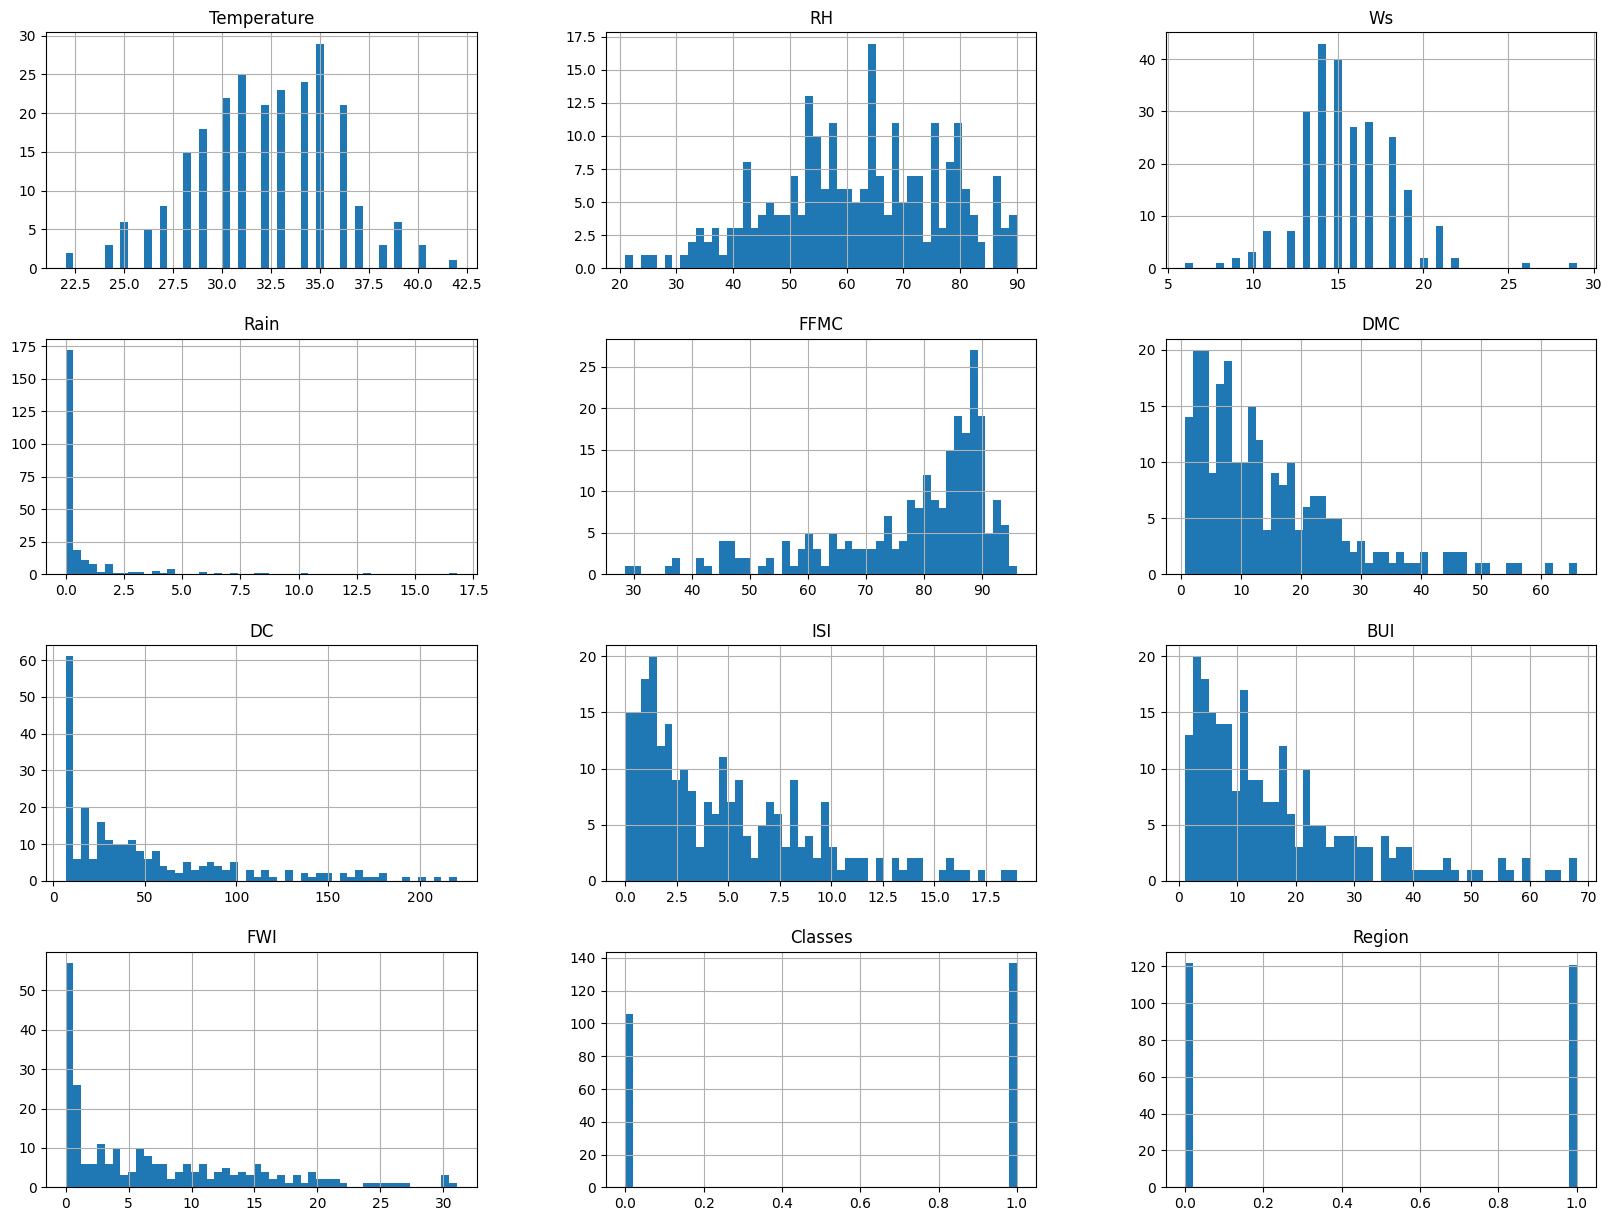

In [12]:
# Plot density plot for all features
# plt.style.use('s')
df_copy.hist(bins=50, figsize=(20,15))
plt.show()

In [13]:
# percentage of pie chart
percentage = df_copy['Classes'].value_counts(normalize=True)*100

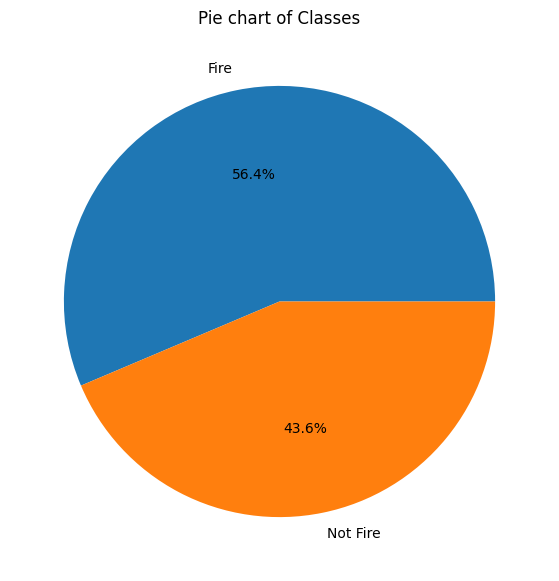

In [14]:
# plotting pie chart
classlabels=['Fire', 'Not Fire']
plt.figure(figsize=(12,7))
plt.pie(percentage,labels=classlabels,autopct='%1.1f%%')
plt.title("Pie chart of Classes")
plt.show()

<Axes: >

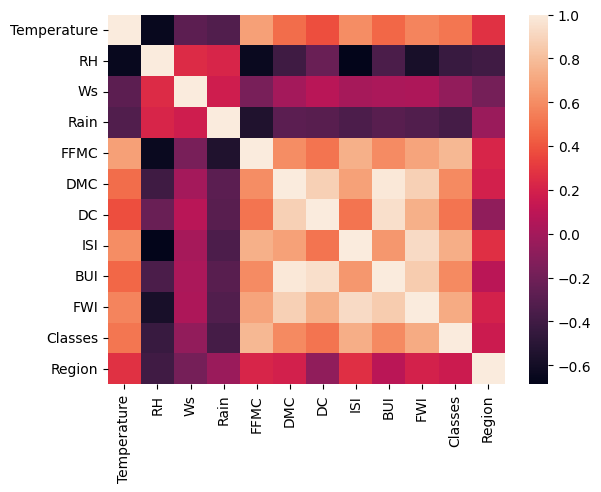

In [15]:
# Correlation
df_copy.corr()
sns.heatmap(df_copy.corr())

<Axes: ylabel='FWI'>

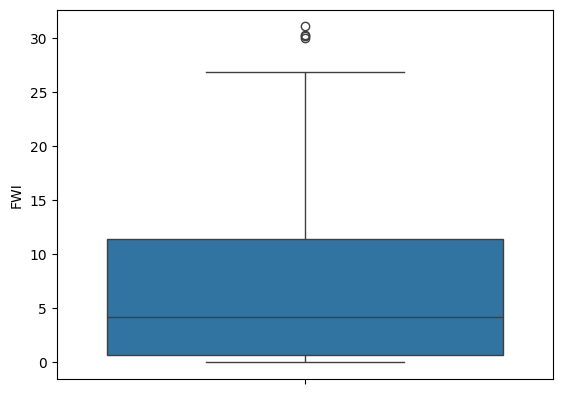

In [16]:
# Box Plots
sns.boxplot(df['FWI'])

In [28]:
df['Classes'] = np.where(df['Classes'].str.contains('not fire'), 'not fire', 'fire')

Text(0.5, 0, 'Months of the Year')

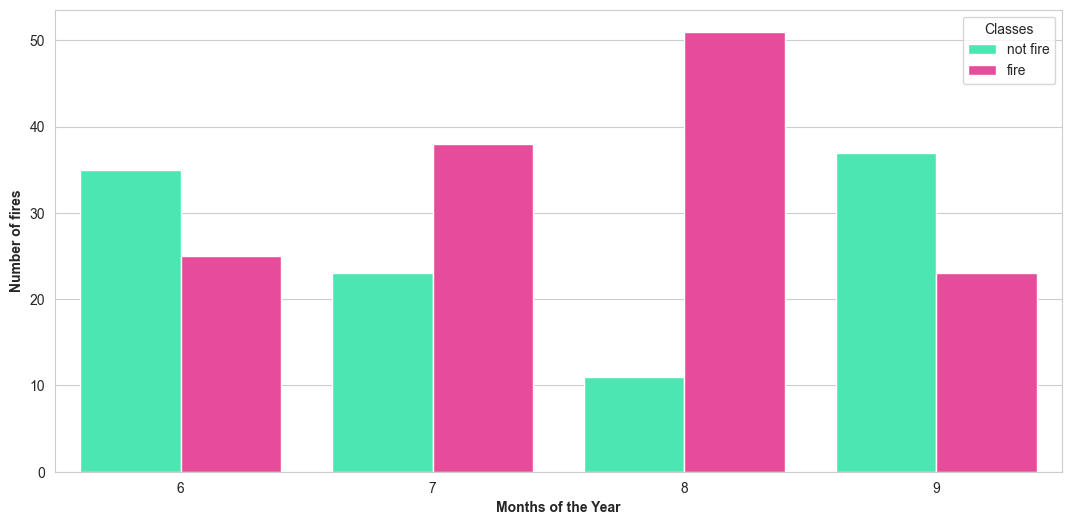

In [38]:
# Monthly fire Analysis
df_temp = df.loc[df['Region']==1]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(
    x='month',
    hue='Classes',
    data=df,
    palette=["#33FFBB", "#FF3399"]  # custom colors
)
plt.ylabel("Number of fires", weight='bold')
plt.xlabel("Months of the Year", weight='bold')